In [ ]:
!pip install osmnx requests certifi rasterio geopandas
import geopandas as gpd
import pandas as pd
import osmnx as ox
import rasterio
import numpy as np
import requests
import certifi
import json
from rasterio.mask import mask
from rasterio.features import shapes

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Wczytano powiat. Liczba obiektów: 2


<Axes: >

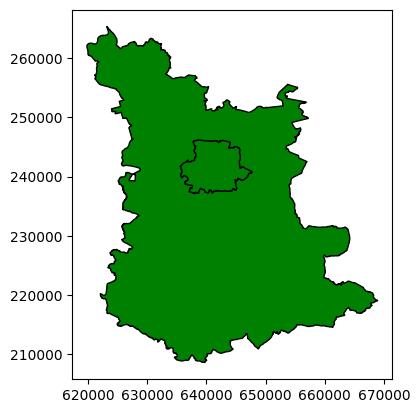

In [ ]:
from google.colab import drive
import geopandas as gpd

drive.mount('/content/drive')

sciezka_tarnowski = "/content/drive/MyDrive/Foto/malopolska/tarnowski.shp"

powiat = gpd.read_file(sciezka_tarnowski)

powiat = powiat.to_crs(epsg=2180)

print(f"Wczytano powiat. Liczba obiektów: {len(powiat)}")
powiat.plot(color='green', edgecolor='black')

In [ ]:
import os
import rasterio
from rasterio.merge import merge

# Pobieranie kafli dla powiatu
bounds = powiat.total_bounds
bbox_str = f"{bounds[1]},{bounds[0]},{bounds[3]},{bounds[2]},EPSG:2180"

WFS_URL = "https://mapy.geoportal.gov.pl/wss/service/PZGIK/NumerycznyModelTerenuEVRF2007/WFS/Skorowidze"
params = {
    "service": "WFS", "version": "2.0.0", "request": "GetFeature",
    "typeNames": "gugik:SkorowidzNMT2022", "bbox": bbox_str,
    "outputFormat": "application/gml+xml; version=3.2"
}

res = requests.get(WFS_URL, params=params, verify=certifi.where())
with open("skorowidz.gml", "wb") as f:
    f.write(res.content)
gdf_skorowidz = gpd.read_file("skorowidz.gml")

# Pobieranie 4 kafli
pobrane_pliki = []
for i in range(min(4, len(gdf_skorowidz))):
    url = gdf_skorowidz.iloc[i]['url_do_pobrania']
    nazwa = f"nmt_{i}.asc"
    r = requests.get(url)
    with open(nazwa, "wb") as f:
        f.write(r.content)
    pobrane_pliki.append(nazwa)
    print(f"Pobrano: {nazwa}")

#tworzenie mozaiki
src_files_to_mosaic = [rasterio.open(p) for p in pobrane_pliki]
mosaic, out_trans = merge(src_files_to_mosaic)


out_meta = src_files_to_mosaic[0].meta.copy()
out_meta.update({
    "height": mosaic.shape[1],
    "width": mosaic.shape[2],
    "transform": out_trans
})

with rasterio.open("mozaika_final.tif", "w", **out_meta) as dest:
    dest.write(mosaic)



In [ ]:
# 1.  środek powiatu
centroid = powiat.union_all().centroid
# bufor 5km wokół środka, żeby znaleźć kafle wewnątrz
center_bbox = f"{centroid.y-2500},{centroid.x-2500},{centroid.y+2500},{centroid.x+2500},EPSG:2180"

params["bbox"] = center_bbox
res = requests.get(WFS_URL, params=params, verify=certifi.where())
with open("skorowidz_center.gml", "wb") as f:
    f.write(res.content)
gdf_center = gpd.read_file("skorowidz_center.gml")

pobrane_pliki = []
for i in range(min(2, len(gdf_center))):
    url = gdf_center.iloc[i]['url_do_pobrania']
    nazwa = f"nmt_center_{i}.asc"
    r = requests.get(url)
    with open(nazwa, "wb") as f:
        f.write(r.content)
    pobrane_pliki.append(nazwa)


In [ ]:
# 1. mozaika
src_files = [rasterio.open(p) for p in pobrane_pliki]
mosaic, out_trans = merge(src_files)

# 2. Analiza nachylenia
data = mosaic[0]
data = np.where(data < -9000, np.nan, data)
dz_dx, dz_dy = np.gradient(data, out_trans[0], -out_trans[4])
slope = np.arctan(np.sqrt(dz_dx**2 + dz_dy**2)) * (180 / np.pi)

# 3. Poligonizacja i Clip
slope_mask = (slope < 5).astype('int16')
mask_gen = shapes(slope_mask, mask=(slope_mask == 1), transform=out_trans)
poligony = [{"geometry": s, "properties": {"slope": "flat"}} for s, v in mask_gen]
gdf_slope = gpd.GeoDataFrame.from_features(poligony, crs="EPSG:2180")

gdf_slope = gdf_slope.clip(powiat)
print(f"wygenerowano {len(gdf_slope)} poligonów wewnątrz powiatu.")

SUKCES! Teraz wygenerowano 2937 poligonów wewnątrz powiatu.


In [ ]:
import osmnx as ox
import folium

# Pobieranie infrastruktury dla powiatu
poly_osm = powiat.to_crs(epsg=4326).union_all()

# Pobieranie drog  i linii energetycznych
gdf_drogi = ox.features_from_polygon(poly_osm, tags={'highway': True})
gdf_power = ox.features_from_polygon(poly_osm, tags={'power': 'line'})

# Konwersja do 2180
gdf_drogi = gdf_drogi.to_crs(epsg=2180)
gdf_power = gdf_power.to_crs(epsg=2180)

# Tworzenie bufora drog i linii energetycznych
buffer_infra = gdf_drogi.geometry.buffer(500).union_all().union(
    gdf_power.geometry.buffer(500).union_all()
)

# finałowe lokalizacje
gdf_final = gdf_slope.clip(buffer_infra)

# Obliczanie powierzchni min. 0.5 ha
gdf_final['area_ha'] = gdf_final.geometry.area / 10000
gdf_final = gdf_final[gdf_final['area_ha'] > 0.5].copy()

print(f"Wytypowano {len(gdf_final)}  lokalizacji pod farmy.")

Pobieram drogi i linie energetyczne...
Tworzę bufor infrastruktury (500m)...
ZAKOŃCZONO! Wytypowano 27 konkretnych lokalizacji pod farmy PV.


In [ ]:
# budynki dla obszaru powiatu
gdf_budynki = ox.features_from_polygon(poly_osm, tags={'building': True})
gdf_budynki = gdf_budynki.to_crs(epsg=2180)

# bufor 100m wokół budynków
bufor_budynki = gdf_budynki.geometry.buffer(100).union_all()
gdf_bufor_budynki = gpd.GeoDataFrame(geometry=[bufor_budynki], crs="EPSG:2180")

# usuwanie stref z budynkami
gdf_final_filtered = gpd.overlay(gdf_final, gdf_bufor_budynki, how='difference')

gdf_final_filtered['area_ha'] = gdf_final_filtered.geometry.area / 10000

gdf_final_filtered = gdf_final_filtered[gdf_final_filtered['area_ha'] > 0.5].copy()

print(f"Pozostało {len(gdf_final_filtered)} lokalizacji pod farmy.")

Pozostało 18 lokalizacji pod farmy.


In [ ]:
#zamiana z m2 na hektary
powierzchnia_powiatu_ha = powiat.geometry.area.sum() / 10000

# Łączna powierzchnia lokalizacji pod farmy
powierzchnia_pv_ha = gdf_final_filtered['area_ha'].sum()

# Procentowy udział terenów nadających się pod farmy
procent_pv = (powierzchnia_pv_ha / powierzchnia_powiatu_ha) * 100

print(f"Całkowita powierzchnia powiatu: {powierzchnia_powiatu_ha:.2f} ha")
print(f"Potencjalna powierzchnia pod farmy PV: {powierzchnia_pv_ha:.2f} ha")
print(f"Procentowy udział farm w powierzchni powiatu: {procent_pv:.3f} %")

--- PODSUMOWANIE WSKAŹNIKÓW ILOŚCIOWYCH ---
Całkowita powierzchnia powiatu: 148294.87 ha
Potencjalna powierzchnia pod farmy PV: 65.75 ha
Procentowy udział farm w powierzchni powiatu: 0.044 %


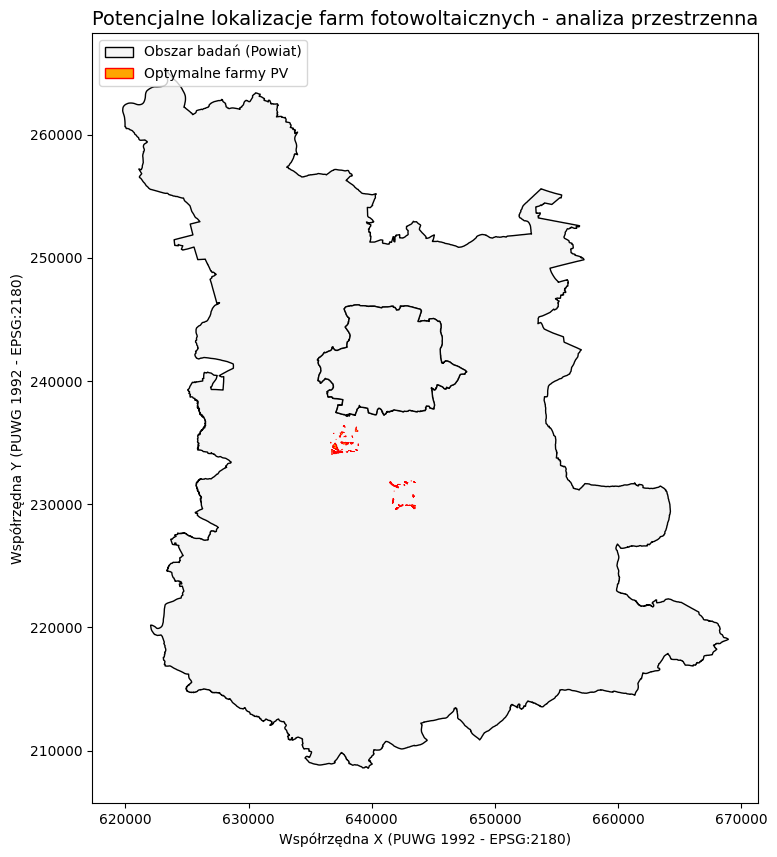

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 10))

powiat.plot(ax=ax, color='whitesmoke', edgecolor='black', linewidth=1)

gdf_final_filtered.plot(ax=ax, color='orange', edgecolor='red', linewidth=0.5)

ax.set_title("Potencjalne lokalizacje farm fotowoltaicznych - analiza przestrzenna", fontsize=14)
ax.set_xlabel("Współrzędna X (PUWG 1992 - EPSG:2180)")
ax.set_ylabel("Współrzędna Y (PUWG 1992 - EPSG:2180)")

legend_pow = mpatches.Patch(color='whitesmoke', label='Obszar badań (Powiat)', ec='black')
legend_pv = mpatches.Patch(color='orange', label='Optymalne farmy PV', ec='red')
ax.legend(handles=[legend_pow, legend_pv], loc='upper left')

plt.show()

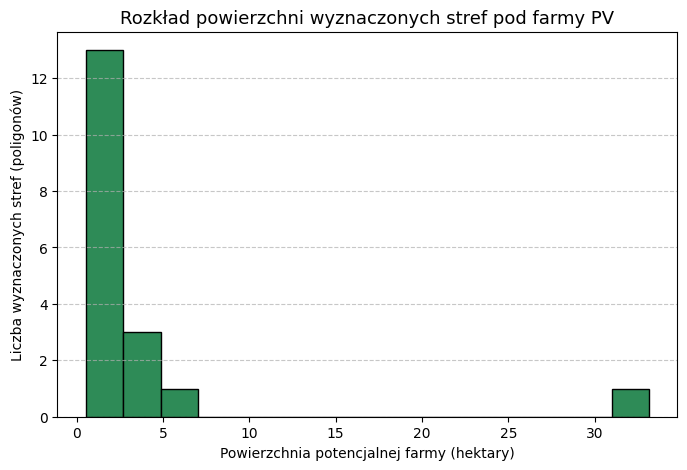

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

gdf_final_filtered['area_ha'].plot(kind='hist', bins=15, color='seagreen', edgecolor='black', ax=ax)

ax.set_title("Rozkład powierzchni wyznaczonych stref pod farmy PV", fontsize=13)
ax.set_xlabel("Powierzchnia potencjalnej farmy (hektary)")
ax.set_ylabel("Liczba wyznaczonych stref (poligonów)")
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [ ]:
m = gdf_final_filtered.explore(
    column='area_ha',
    cmap='YlOrRd',
    name="Potencjalne Farmy PV",
    tooltip=['area_ha'],
    popup=True,
    style_kwds={'fillOpacity': 0.7}
)

powiat.explore(m=m, color='black', name="Granica Powiatu", style_kwds={'fill':False, 'weight':3})

folium.LayerControl().add_to(m)
m.save("finalny_projekt_PV.html")
